In [4]:
!pip install pandas numpy matplotlib seaborn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
orders_df = pd.read_csv("orders.csv")

orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48998 entries, 0 to 48997
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               48998 non-null  int64  
 1   order_number     48998 non-null  object 
 2   channel          48998 non-null  object 
 3   customer_id      48998 non-null  int64  
 4   salesperson_id   24867 non-null  float64
 5   location_id      48998 non-null  int64  
 6   status           48998 non-null  object 
 7   subtotal         48998 non-null  float64
 8   discount_amount  48998 non-null  float64
 9   total            48998 non-null  float64
 10  placed_at        48998 non-null  object 
 11  created_at       48998 non-null  object 
 12  updated_at       48998 non-null  object 
dtypes: float64(4), int64(3), object(6)
memory usage: 4.9+ MB


In [7]:
orders_df.head()

,id,order_number,channel,customer_id,salesperson_id,location_id,status,subtotal,discount_amount,total,placed_at,created_at,updated_at
0,1,SO-000001,ecommerce,1136,NaN,1,paid,323.34,35.57,287.77,2022-09-06 05:37:37,2022-09-06 05:37:37,2022-09-06 05:37:37
1,2,SO-000002,ecommerce,618,9.0,4,paid,53199.05,0.00,53199.05,2023-02-03 04:36:21,2023-02-03 04:36:21,2023-02-03 04:36:21
2,3,SO-000003,pos,227,10.0,4,confirmed,17157.39,0.00,17157.39,2024-12-30 07:15:17,2024-12-30 07:15:17,2024-12-30 07:15:17
3,4,SO-000004,ecommerce,1123,NaN,3,paid,11095.62,665.74,10429.88,2024-03-12 20:39:36,2024-03-12 20:39:36,2024-03-12 20:39:36
4,5,SO-000005,ecommerce,426,9.0,2,confirmed,32842.03,0.00,32842.03,2020-03-27 13:52:12,2020-03-27 13:52:12,2020-03-27 13:52:12


In [56]:
mean_total = orders_df["total"].mean()

print(f"Valor médio dos pedidos: {mean_total:.2f} reais")

Valor médio dos pedidos: 28704.99 reais


In [8]:
nulls = pd.DataFrame({
    "quantity": orders_df.isnull().sum(),
    "percentage": orders_df.isnull().mean() * 100
})

nulls["percentage"] = nulls["percentage"].round(2)

nulls = nulls.sort_values("percentage", ascending=False)

nulls

,quantity,percentage
salesperson_id,24131,49.25
id,0,0.00
order_number,0,0.00
channel,0,0.00
customer_id,0,0.00
location_id,0,0.00
status,0,0.00
subtotal,0,0.00
discount_amount,0,0.00
total,0,0.00


In [9]:
# quase metade dos pedidos nao tem id do vendedor
  # isso pode significar que os pedidos foram feitos diretamente pelo cliente
  # ou que o id do vendedor nao foi informado na compra

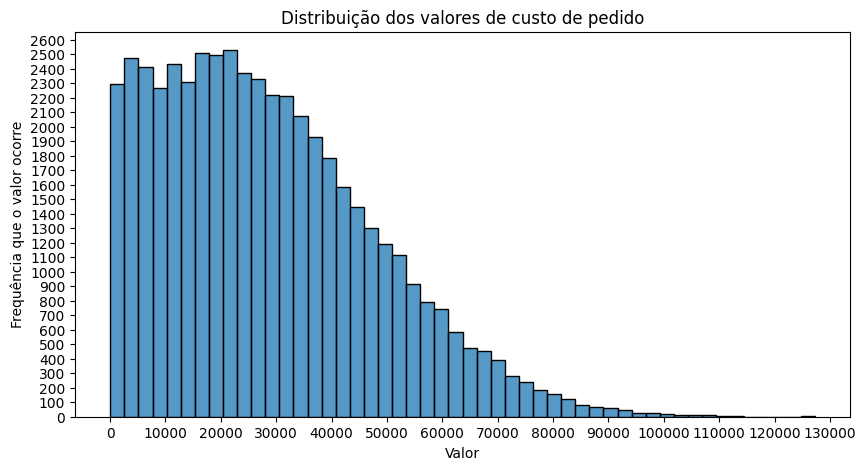

In [44]:
from matplotlib.ticker import MultipleLocator

plt.figure(figsize=(10, 5))

sns.histplot(orders_df["total"], bins=50)

plt.title("Distribuição dos valores de custo de pedido")
plt.xlabel("Valor")
plt.ylabel("Frequência que o valor ocorre")

plt.gca().xaxis.set_major_locator(MultipleLocator(10000))
plt.gca().yaxis.set_major_locator(MultipleLocator(100))

plt.show()

In [68]:
# dividindo os valores dos pedidos em intervalos
  # para saber em qual faixa os pedidos mais ocorrem

total_values = orders_df["total"].dropna()
counts, bin_edges = np.histogram(
    total_values,
    bins=4
)

mean_total = total_values.mean()

max_bin_index = counts.argmax()
percentages = (counts / len(total_values)) * 100

lowerbound = bin_edges[max_bin_index]
upperbound = bin_edges[max_bin_index + 1]
max_count = counts[max_bin_index]

print("Quantidade de pedidos por intervalo:")
for i in range(len(counts)):
    print(
        f"Intervalo {i + 1}: "
        f"R$ {bin_edges[i]:.2f} até R$ {bin_edges[i + 1]:.2f} "
        f"-> {counts[i]} pedidos"
        f"({percentages[i]:.2f}%)"
    )

print("\n\n")

print("Intervalo com maior quantidade de pedidos:")
print(f"Intervalo: {max_bin_index + 1}")
print(f"Valor mínimo: {lowerbound:.2f}")
print(f"Valor máximo: {upperbound:.2f}")
print(f"Valor médio dos pedidos: R$ {mean_total:.2f}")
print(f"Quantidade de pedidos: {max_count}")
print(f"Porcentagem dos pedidos: {percentages[max_bin_index]:.2f}%")

Quantidade de pedidos por intervalo:
Intervalo 1: R$ 32.62 até R$ 31839.97 -> 29766 pedidos(60.75%)
Intervalo 2: R$ 31839.97 até R$ 63647.32 -> 16542 pedidos(33.76%)
Intervalo 3: R$ 63647.32 até R$ 95454.67 -> 2576 pedidos(5.26%)
Intervalo 4: R$ 95454.67 até R$ 127262.02 -> 114 pedidos(0.23%)



Intervalo com maior quantidade de pedidos:
Intervalo: 1
Valor mínimo: 32.62
Valor máximo: 31839.97
Valor médio dos pedidos: R$ 28704.99
Quantidade de pedidos: 29766
Porcentagem dos pedidos: 60.75%


In [77]:
# analisando pedidos de maior valor e seu impacto na arrecadacao

highest_value_orders = orders_df[
    orders_df["total"] > 100000
]

highest_value_percentage = (
    len(highest_value_orders) / len(orders_df)
) * 100

print(
    "Quantidade de pedidos com valor maior que 100.000 reais:",
    len(highest_value_orders)
)

print(
    f"Porcentagem: "
    f"{highest_value_percentage:.2f}%"
)


total_revenue = orders_df["total"].sum()
highest_value_revenue = highest_value_orders["total"].sum()
highest_value_revenue_percentage = (
    highest_value_revenue / total_revenue
) * 100

print(
    f"\nValor arrecadado por esses pedidos: "
    f"R$ {highest_value_revenue:,.2f}"
)

print(
    f"Porcentagem do faturamento representada por esses pedidos: "
    f"{highest_value_revenue_percentage:.2f}%"
)

Quantidade de pedidos com valor maior que 100.000 reais: 66
Porcentagem: 0.13%

Valor arrecadado por esses pedidos: R$ 7,004,788.64
Porcentagem do faturamento representada por esses pedidos: 0.50%


In [76]:
inconsistent_paid_value = orders_df[
    orders_df["total"] != orders_df["subtotal"] - orders_df["discount_amount"]
]

print(f"Quantidade de pedidos com valores inconsistentes: {len(inconsistent_paid_value)}")

print("\nExemplos de pedidos com valores inconsistentes:")
print(
    inconsistent_paid_value[
        ["id", "order_number", "subtotal", "discount_amount", "total"]
    ].head(10)
)

Quantidade de pedidos com valores inconsistentes: 3536

Exemplos de pedidos com valores inconsistentes:
      id order_number  subtotal  discount_amount     total
3      4    SO-000004  11095.62           665.74  10429.88
17    19    SO-000019  16377.79          2292.89  14084.90
20    22    SO-000022  56845.27          2842.26  54003.01
26    29    SO-000029  36020.60          5042.88  30977.72
37    40    SO-000040  17280.24          1555.22  15725.02
41    44    SO-000044  41669.38          4166.94  37502.44
59    62    SO-000062   6306.52           882.91   5423.61
71    74    SO-000074   6414.28           641.43   5772.85
94    97    SO-000097   8383.80           586.87   7796.93
117  120    SO-000120  24229.44           726.88  23502.56


In [18]:
# verificacao de novo apos ajuste considerando arredondamento de float

inconsistent_paid_value = orders_df[
    ~np.isclose(
        orders_df["total"],
        orders_df["subtotal"] - orders_df["discount_amount"],
        rtol=0,
        atol=0.01
    )
]

print(f"Quantidade de pedidos com valores inconsistentes: {len(inconsistent_paid_value)}")

print("\nExemplos de pedidos com valores inconsistentes:")
print(
    inconsistent_paid_value[
        ["id", "order_number", "subtotal", "discount_amount", "total"]
    ].head(10)
)

Quantidade de pedidos com valores inconsistentes: 0

Exemplos de pedidos com valores inconsistentes:
Empty DataFrame
Columns: [id, order_number, subtotal, discount_amount, total]
Index: []


In [38]:
# verificando existencia de pedidos com valores 0 ou negativos

zero_values = (orders_df["total"] == 0).sum()
negative_values = (orders_df["total"] < 0).sum()

print("Quantidade de valores 0:", zero_values)
print("Quantidade de valores negativos:", negative_values)

Quantidade de valores 0: 0
Quantidade de valores negativos: 0


In [36]:
print("Quantidade de valores únicos por coluna:")
print(orders_df.nunique(dropna=False))

print("\n\n")

print("\nValores únicos de vendedor:")
print(orders_df["salesperson_id"].unique())

print("\nValores únicos de channel:")
print(orders_df["channel"].unique())

print("\nValores únicos de status:")
print(orders_df["status"].unique())

Quantidade de valores únicos por coluna:
id                 48998
order_number       48998
channel                2
customer_id         2000
salesperson_id         4
location_id            6
status                 4
subtotal           45374
discount_amount    12228
total              46738
placed_at          48990
created_at         48990
updated_at         48990
dtype: int64




Valores únicos de vendedor:
[nan  9. 10.  6.]

Valores únicos de channel:
['ecommerce' 'pos']

Valores únicos de status:
['paid' 'confirmed' 'cancelled' 'draft']


In [28]:
channel_counts = orders_df["channel"].value_counts(dropna=False)
channel_percentages = orders_df["channel"].value_counts(
    normalize=True,
    dropna=False
) * 100

print("Quantidade por canal de venda:")
print(
    pd.DataFrame({
        "quantidade": channel_counts,
        "porcentagem": channel_percentages.round(2)
    })
)
print("\n")


status_counts = orders_df["status"].value_counts(dropna=False)
status_percentages = orders_df["status"].value_counts(
    normalize=True,
    dropna=False
) * 100

print("\nQuantidade por status do pedido:")
print(
    pd.DataFrame({
        "quantidade": status_counts,
        "porcentagem": status_percentages.round(2)
    })
)
print("\n")


salesperson_counts = orders_df["salesperson_id"].value_counts(
    dropna=False
)
salesperson_percentages = orders_df["salesperson_id"].value_counts(
    normalize=True,
    dropna=False
) * 100

print("\nQuantidade por vendedor:")
print(
    pd.DataFrame({
        "quantidade": salesperson_counts,
        "porcentagem": salesperson_percentages.round(2)
    })
)

Quantidade por canal de venda:
           quantidade  porcentagem
channel                           
ecommerce       34342        70.09
pos             14656        29.91



Quantidade por status do pedido:
           quantidade  porcentagem
status                            
paid            34365        70.14
confirmed        7335        14.97
cancelled        4847         9.89
draft            2451         5.00



Quantidade por vendedor:
                quantidade  porcentagem
salesperson_id                         
NaN                  24131        49.25
9.0                   8354        17.05
6.0                   8259        16.86
10.0                  8254        16.85


In [30]:
# verificando se todos os pedidos sem vendedor foram feitos online

orders_without_salesperson = orders_df[
    orders_df["salesperson_id"].isna()
]

channel_counts = orders_without_salesperson["channel"].value_counts()

channel_percentages = (
    orders_without_salesperson["channel"]
    .value_counts(normalize=True)
    * 100
)

result = pd.DataFrame({
    "quantidade": channel_counts,
    "porcentagem": channel_percentages.round(2)
})

print("Pedidos sem vendedor por canal:")
print(result)

Pedidos sem vendedor por canal:
           quantidade  porcentagem
channel                           
ecommerce       24131        100.0


In [39]:
# avaliando presenca de vendedor por pedido e canal

channel_salesperson_analysis = (
    orders_df
    .groupby("channel")
    .agg(
        total_pedidos=("id", "count"),

        pedidos_com_vendedor=(
            "salesperson_id",
            lambda x: x.notna().sum()
        ),

        pedidos_sem_vendedor=(
            "salesperson_id",
            lambda x: x.isna().sum()
        )
    )
)

channel_salesperson_analysis["percentual_sem_vendedor"] = (
    channel_salesperson_analysis["pedidos_sem_vendedor"]
    / channel_salesperson_analysis["total_pedidos"]
    * 100
).round(2)

print(channel_salesperson_analysis)

           total_pedidos  pedidos_com_vendedor  pedidos_sem_vendedor  \
channel                                                                
ecommerce          34342                 10211                 24131   
pos                14656                 14656                     0   

           percentual_sem_vendedor  
channel                             
ecommerce                    70.27  
pos                           0.00  


In [40]:
# avaliando vendas de cada vendedor no ecommerce

ecommerce_orders = orders_df[
    orders_df["channel"] == "ecommerce"
]

salesperson_counts = (ecommerce_orders["salesperson_id"].dropna().value_counts())

salesperson_percentages = (ecommerce_orders["salesperson_id"].dropna().value_counts(normalize=True)* 100)

ecommerce_salespeople = pd.DataFrame({
    "quantidade_vendas": salesperson_counts,
    "porcentagem": salesperson_percentages.round(2)
})

print("Vendas do ecommerce por vendedor:")
print(ecommerce_salespeople)

Vendas do ecommerce por vendedor:
                quantidade_vendas  porcentagem
salesperson_id                                
6.0                          3438        33.67
9.0                          3394        33.24
10.0                         3379        33.09
